# Heart Disease Risk Project — Arpit Role

This notebook performs:
- Dataset loading
- Dataset overview (Table 1)
- Feature description table (Table 2)
- Class distribution plot (P1)
- Correlation heatmap (P2)
- Missing value handling
- Train/Test split
- Feature scaling
- Logistic Regression training
- Extraction and normalization of LR coefficients (Table 3)
- Saving outputs required by the team

Outputs generated:
- cleaned_train.csv
- cleaned_test.csv
- LR_coefficients.csv


In [1]:
# Install required libraries (run once if needed)
!pip install pandas numpy scikit-learn seaborn matplotlib

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

## Load Dataset

In [22]:
# Load dataset
df = pd.read_csv("../data/heart_disease_uci.csv")

# Create binary target
df['target'] = (df['num'] > 0).astype(int)

# Drop original target column
df = df.drop('num', axis=1)

# Handle missing values
df = df.fillna(df.mean(numeric_only=True))

# Convert categorical variables to numeric
df = pd.get_dummies(df, drop_first=True)

## Table 1 — Dataset Overview

In [23]:
rows, cols = df.shape
print('Rows:', rows)
print('Columns:', cols)

print('\nTarget Distribution:')
print(df['target'].value_counts())

Rows: 920
Columns: 23

Target Distribution:
target
1    509
0    411
Name: count, dtype: int64


## Table 2 — Feature Description

In [25]:
feature_table = pd.DataFrame({
    'Feature Name': df.columns,
    'Data Type': df.dtypes
})

feature_table

,Feature Name,Data Type
id,id,int64
age,age,int64
trestbps,trestbps,float64
chol,chol,float64
thalch,thalch,float64
oldpeak,oldpeak,float64
ca,ca,float64
target,target,int64
sex_Male,sex_Male,bool
dataset_Hungary,dataset_Hungary,bool


## Plot 1 — Class Distribution

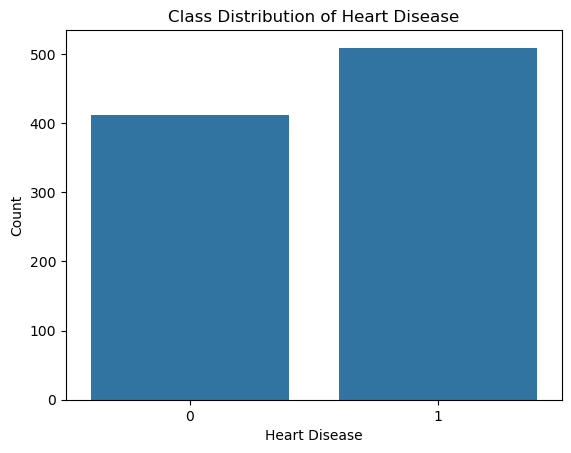

In [26]:
plt.figure()
sns.countplot(x='target', data=df)
plt.title('Class Distribution of Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Count')
plt.savefig('../figures/class_distribution.png')
plt.show()

## Handle Missing Values

In [27]:
df = df.fillna(df.mean(numeric_only=True))

## Plot 2 — Correlation Heatmap

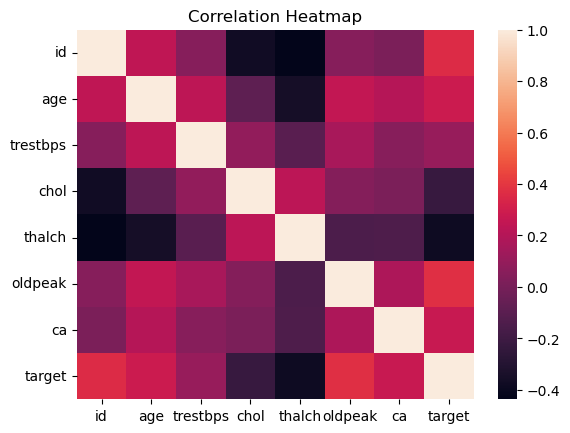

In [28]:
plt.figure()

# select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

corr = numeric_df.corr()

sns.heatmap(corr)

plt.title("Correlation Heatmap")

plt.savefig("../figures/correlation_heatmap.png")

plt.show()

## Train-Test Split

In [31]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Feature Scaling

In [33]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Train Logistic Regression

In [34]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

## Table 3 — Logistic Regression Coefficients

In [35]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
})

coefficients['Normalized Weight'] = (
    abs(coefficients['Coefficient']) /
    abs(coefficients['Coefficient']).sum()
)

coefficients

,Feature,Coefficient,Normalized Weight
0,id,1.895883,0.195416
1,age,-0.010756,0.001109
2,trestbps,0.078301,0.008071
3,chol,0.085036,0.008765
4,thalch,-0.027561,0.002841
5,oldpeak,0.611948,0.063076
6,ca,0.598791,0.061720
7,sex_Male,0.574406,0.059206
8,dataset_Hungary,-1.059078,0.109163
9,dataset_Switzerland,-0.173204,0.017853


## Save Outputs Required by Team

In [37]:
# Save LR coefficients
coefficients.to_csv('../outputs/LR_coefficients.csv', index=False)

# Save cleaned training dataset
train_df = pd.concat([
    pd.DataFrame(X_train_scaled, columns=X.columns),
    y_train.reset_index(drop=True)
], axis=1)

train_df.to_csv('../outputs/cleaned_train.csv', index=False)

# Save cleaned testing dataset
test_df = pd.concat([
    pd.DataFrame(X_test_scaled, columns=X.columns),
    y_test.reset_index(drop=True)
], axis=1)

test_df.to_csv('../outputs/cleaned_test.csv', index=False)

print('Files saved successfully.')

Files saved successfully.


In [1]:
import os
print(os.getcwd())

/Users/arpitayushmanmishra/Major Heart_Disease_Project/Notebooks


In [2]:
import pandas as pd

df = pd.read_csv("../outputs/cleaned_train.csv")

df.columns

Index(['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'sex_Male',
       'dataset_Hungary', 'dataset_Switzerland', 'dataset_VA Long Beach',
       'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'fbs_True',
       'restecg_normal', 'restecg_st-t abnormality', 'exang_True',
       'slope_flat', 'slope_upsloping', 'thal_normal',
       'thal_reversable defect', 'target'],
      dtype='object')

In [3]:
df.dtypes

id                          float64
age                         float64
trestbps                    float64
chol                        float64
thalch                      float64
oldpeak                     float64
ca                          float64
sex_Male                    float64
dataset_Hungary             float64
dataset_Switzerland         float64
dataset_VA Long Beach       float64
cp_atypical angina          float64
cp_non-anginal              float64
cp_typical angina           float64
fbs_True                    float64
restecg_normal              float64
restecg_st-t abnormality    float64
exang_True                  float64
slope_flat                  float64
slope_upsloping             float64
thal_normal                 float64
thal_reversable defect      float64
target                        int64
dtype: object

In [4]:
df["target"].value_counts()

target
1    400
0    336
Name: count, dtype: int64

In [5]:
df.shape

(736, 23)

In [6]:
df.isnull().sum()

id                          0
age                         0
trestbps                    0
chol                        0
thalch                      0
oldpeak                     0
ca                          0
sex_Male                    0
dataset_Hungary             0
dataset_Switzerland         0
dataset_VA Long Beach       0
cp_atypical angina          0
cp_non-anginal              0
cp_typical angina           0
fbs_True                    0
restecg_normal              0
restecg_st-t abnormality    0
exang_True                  0
slope_flat                  0
slope_upsloping             0
thal_normal                 0
thal_reversable defect      0
target                      0
dtype: int64

In [1]:
import os

os.makedirs("../tables", exist_ok=True)

In [8]:
import pandas as pd
import os

In [10]:
df = pd.read_csv("../outputs/cleaned_train.csv")

In [11]:
os.makedirs("../tables", exist_ok=True)

In [12]:
table1 = pd.DataFrame({
    "Metric": ["Rows", "Columns"],
    "Value": [df.shape[0], df.shape[1]]
})

table1.to_csv("../tables/T1_dataset_overview.csv", index=False)

In [13]:
table2 = pd.DataFrame({
    "Feature Name": df.columns,
    "Data Type": df.dtypes
})

table2.to_csv("../tables/T2_feature_description.csv", index=False)

table2.head()

,Feature Name,Data Type
id,id,float64
age,age,float64
trestbps,trestbps,float64
chol,chol,float64
thalch,thalch,float64


In [16]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

In [17]:
df = pd.read_csv("../outputs/cleaned_train.csv")

In [18]:
X = df.drop("target", axis=1)
y = df["target"]

In [19]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X, y)

LogisticRegression(max_iter=1000)

In [20]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_[0]
})

coefficients["Normalized Weight"] = (
    abs(coefficients["Coefficient"]) /
    abs(coefficients["Coefficient"]).sum()
)

coefficients.head()

,Feature,Coefficient,Normalized Weight
0,id,1.895883,0.195416
1,age,-0.010756,0.001109
2,trestbps,0.078301,0.008071
3,chol,0.085036,0.008765
4,thalch,-0.027561,0.002841


In [21]:
coefficients.to_csv("../tables/T3_lr_coefficients.csv", index=False)

In [22]:
import os
os.listdir("../tables")

['T1_dataset_overview.csv',
 'T3_lr_coefficients.csv',
 'T2_feature_description.csv']

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Load original dataset
df = pd.read_csv("../data/heart_disease_uci.csv")

# Drop ID column if present
if "id" in df.columns:
    df = df.drop("id", axis=1)

# Create binary target
df['target'] = (df['num'] > 0).astype(int)

# Remove original column
df = df.drop("num", axis=1)

# Handle missing values
df = df.fillna(df.mean(numeric_only=True))

# One-hot encoding
df = pd.get_dummies(df, drop_first=True)

# Split features and target
X = df.drop("target", axis=1)
y = df["target"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Generate coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_[0]
})

coefficients["Normalized Weight"] = (
    abs(coefficients["Coefficient"]) /
    abs(coefficients["Coefficient"]).sum()
)

In [4]:
# Save updated datasets
train_df = pd.concat([
    pd.DataFrame(X_train_scaled, columns=X.columns),
    y_train.reset_index(drop=True)
], axis=1)

test_df = pd.concat([
    pd.DataFrame(X_test_scaled, columns=X.columns),
    y_test.reset_index(drop=True)
], axis=1)

train_df.to_csv("../outputs/cleaned_train.csv", index=False)
test_df.to_csv("../outputs/cleaned_test.csv", index=False)

# Save updated LR coefficients
coefficients.to_csv("../outputs/LR_coefficients.csv", index=False)
coefficients.to_csv("../tables/T3_lr_coefficients.csv", index=False)

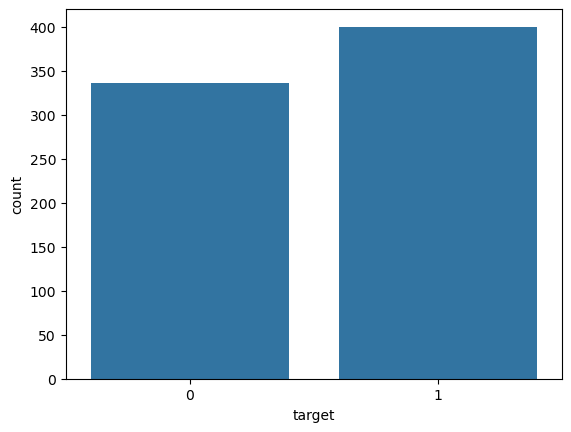

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.countplot(x="target", data=train_df)
plt.savefig("../figures/class_distribution.png")

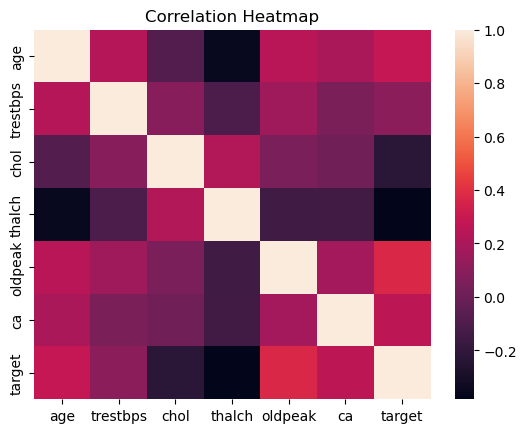

In [9]:
plt.figure()

# select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

corr = numeric_df.corr()

sns.heatmap(corr)

plt.title("Correlation Heatmap")

plt.savefig("../figures/correlation_heatmap.png")

plt.show()

In [10]:
import os
os.system("open ..")

0